In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_tm_roc_curve, plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_color_thermometers_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_aggregated_heatmap, visualize_per_channel_heatmaps, visualize_per_channel_level_heatmaps, visualize_average_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-09 12:42:06,003 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data


2026-03-09 12:42:06,020 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib


2026-03-09 12:42:06,034 - matplotlib - DEBUG - interactive is False


2026-03-09 12:42:06,034 - matplotlib - DEBUG - platform is linux


2026-03-09 12:42:06,122 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib


2026-03-09 12:42:06,126 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
resolution=4

In [3]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [4]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [5]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_color_thermometers_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test, resolution)

In [6]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [7]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=0)

[I 2026-03-09 12:42:06,869] A new study created in memory with name: no-name-4554b3c0-facb-46de-a6ae-8b5ddcbff824


[I 2026-03-09 12:48:47,325] Trial 0 finished with value: 0.7339449541284404 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7339449541284404.


[I 2026-03-09 12:55:25,342] Trial 1 finished with value: 0.7547169811320755 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 1 with value: 0.7547169811320755.


[I 2026-03-09 13:02:36,640] Trial 2 finished with value: 0.7692307692307693 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.7692307692307693.


[I 2026-03-09 13:09:28,877] Trial 3 finished with value: 0.8018867924528302 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.8018867924528302.


...

[I 2026-03-09 17:31:24,622] Trial 46 finished with value: 0.8256880733944955 and parameters: {'s': 14.0, 'T': 3000, 'patch_size': 9, 'max_included_literals': 64}. Best is trial 31 with value: 0.8256880733944955.


[I 2026-03-09 17:33:36,239] Trial 47 finished with value: 0.7211538461538461 and parameters: {'s': 14.0, 'T': 3000, 'patch_size': 9, 'max_included_literals': 64}. Best is trial 31 with value: 0.8256880733944955.


[I 2026-03-09 17:35:51,204] Trial 48 finished with value: 0.794392523364486 and parameters: {'s': 13.0, 'T': 4500, 'patch_size': 9, 'max_included_literals': 64}. Best is trial 31 with value: 0.8256880733944955.


[I 2026-03-09 17:38:05,194] Trial 49 finished with value: 0.8018867924528302 and parameters: {'s': 14.0, 'T': 3500, 'patch_size': 9, 'max_included_literals': 64}. Best is trial 31 with value: 0.8256880733944955.


Best fbeta: 0.8256880733944955
Best hyperparameters: {'s': 15.0, 'T': 3000, 'patch_size': 9, 'max_included_literals': 64}


In [8]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/color_thermometers_resolution_4.json")

Best F1 score macro accuracy: 0.8256880733944955
Best hyperparameters: {'s': 15.0, 'T': 3000, 'patch_size': 9, 'max_included_literals': 64}
Best Optuna results saved to hyperparameters/color_thermometers_resolution_4.json


In [9]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers_resolution_4.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [10]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BreastMNIST_Color_Thermometers_resolution_4",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 69.87% (21.50s)


#2 Accuracy: 76.28% (24.45s)


#3 Accuracy: 78.21% (23.91s)


#4 Accuracy: 75.00% (23.16s)


...

#96 Accuracy: 86.54% (16.05s)


#97 Accuracy: 86.54% (16.03s)


#98 Accuracy: 88.46% (15.99s)


#99 Accuracy: 88.46% (16.04s)


#100 Accuracy: 87.82% (16.02s)


In [11]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BreastMNIST_Color_Thermometers_Specialist_resolution_4.pkl")

In [12]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [13]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

2026-03-09 18:09:03,829 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-03-09 18:09:03,832 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


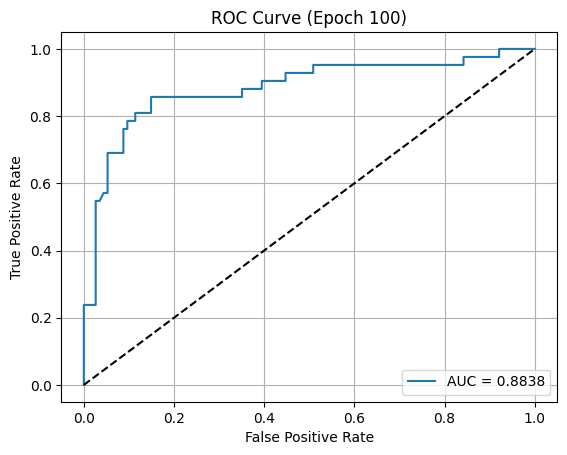

0.8837719298245614

In [14]:
plot_tm_roc_curve(config, T_best, s_best, patch_best, maxlit_best, weighted_best, 
                Y_test, "BreastMNIST_Color_Thermometers_resolution_4")

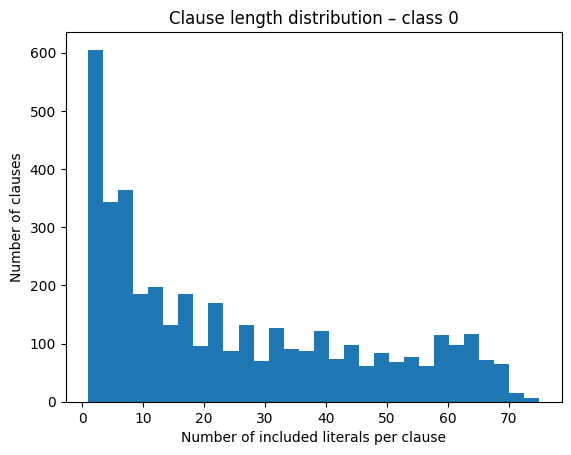

Class 0: median=18.0, mean=24.8, std=21.1


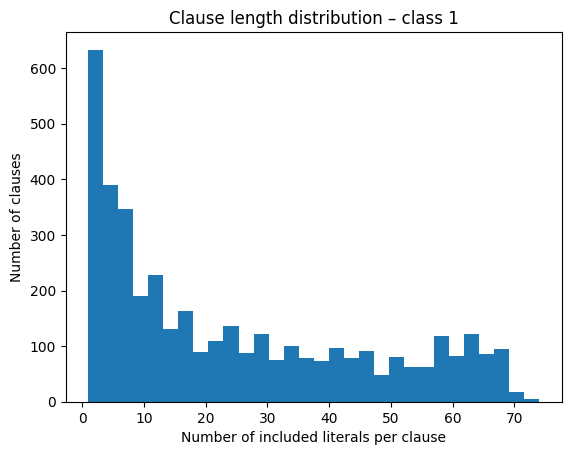

Class 1: median=17.0, mean=24.4, std=21.3


In [15]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 87.82%
2026-03-09 18:09:04,513 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bfe4a70>


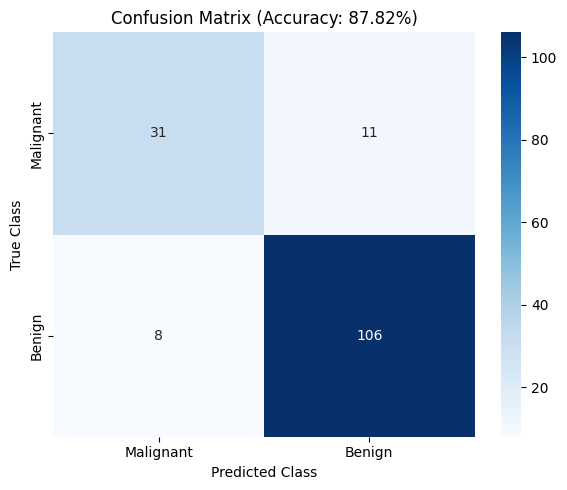

In [16]:
_, _ =  plot_confusion_matrix_from_scores(config,  T_best, s_best, patch_best, maxlit_best, weighted_best, 
                                   Y_test, "BreastMNIST_Color_Thermometers_resolution_4")

Showing sample index: 103


2026-03-09 18:09:11,800 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a524708bf0>


2026-03-09 18:09:11,955 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bf62930>


2026-03-09 18:09:12,072 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bf63d10>


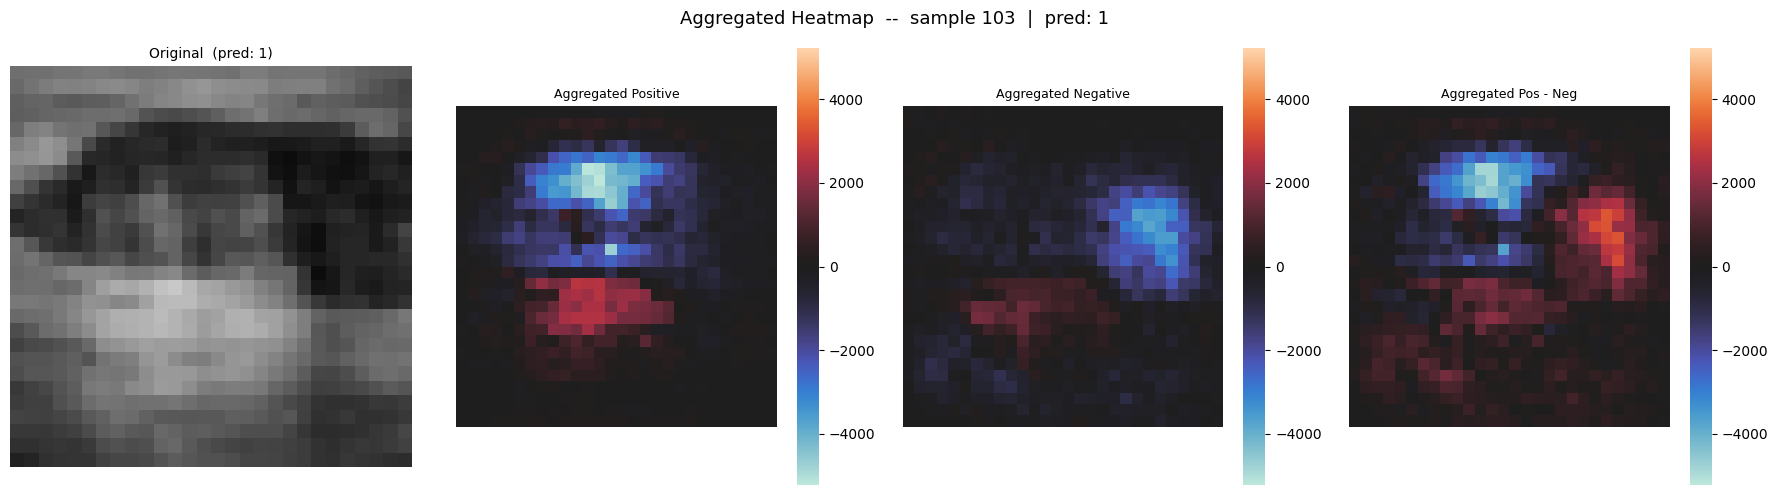

2026-03-09 18:09:19,449 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bdb0cb0>


2026-03-09 18:09:19,614 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51be978f0>


2026-03-09 18:09:19,740 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51ba45af0>


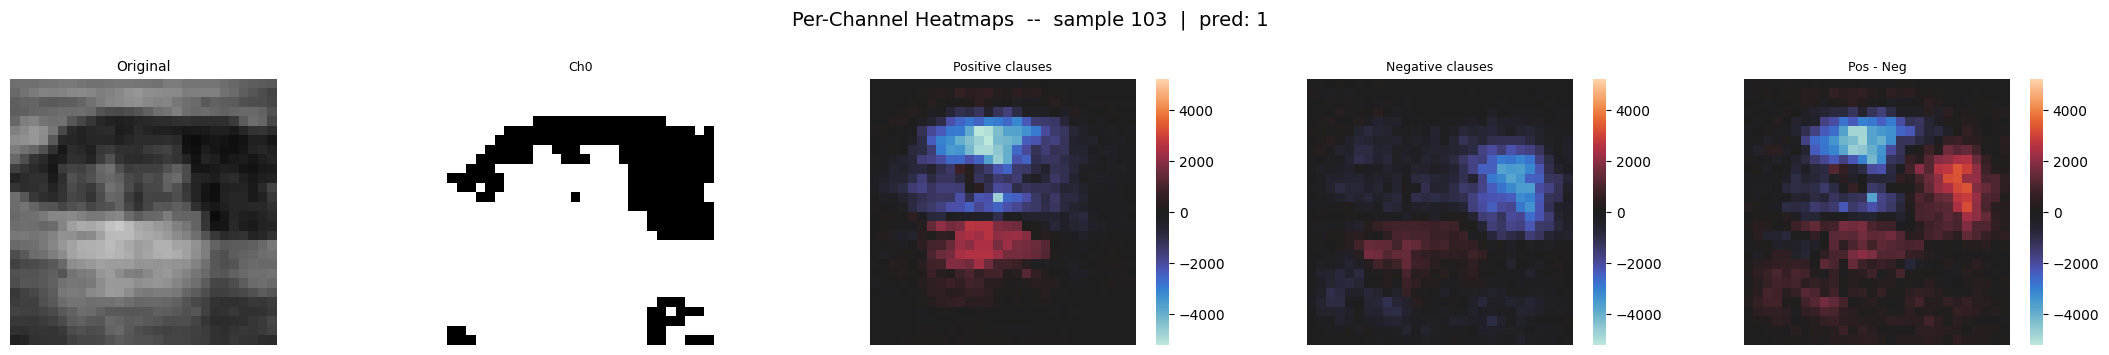

2026-03-09 18:09:27,211 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51b799010>


2026-03-09 18:09:27,753 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bbeae40>


2026-03-09 18:09:28,056 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51be618b0>


2026-03-09 18:09:28,364 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bae8740>


2026-03-09 18:09:28,665 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bf60740>


...

2026-03-09 18:09:29,570 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51bd683e0>


2026-03-09 18:09:29,866 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51ba78290>


2026-03-09 18:09:30,165 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51b6992e0>


2026-03-09 18:09:30,463 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51baa0740>


2026-03-09 18:09:30,759 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78a51b569940>


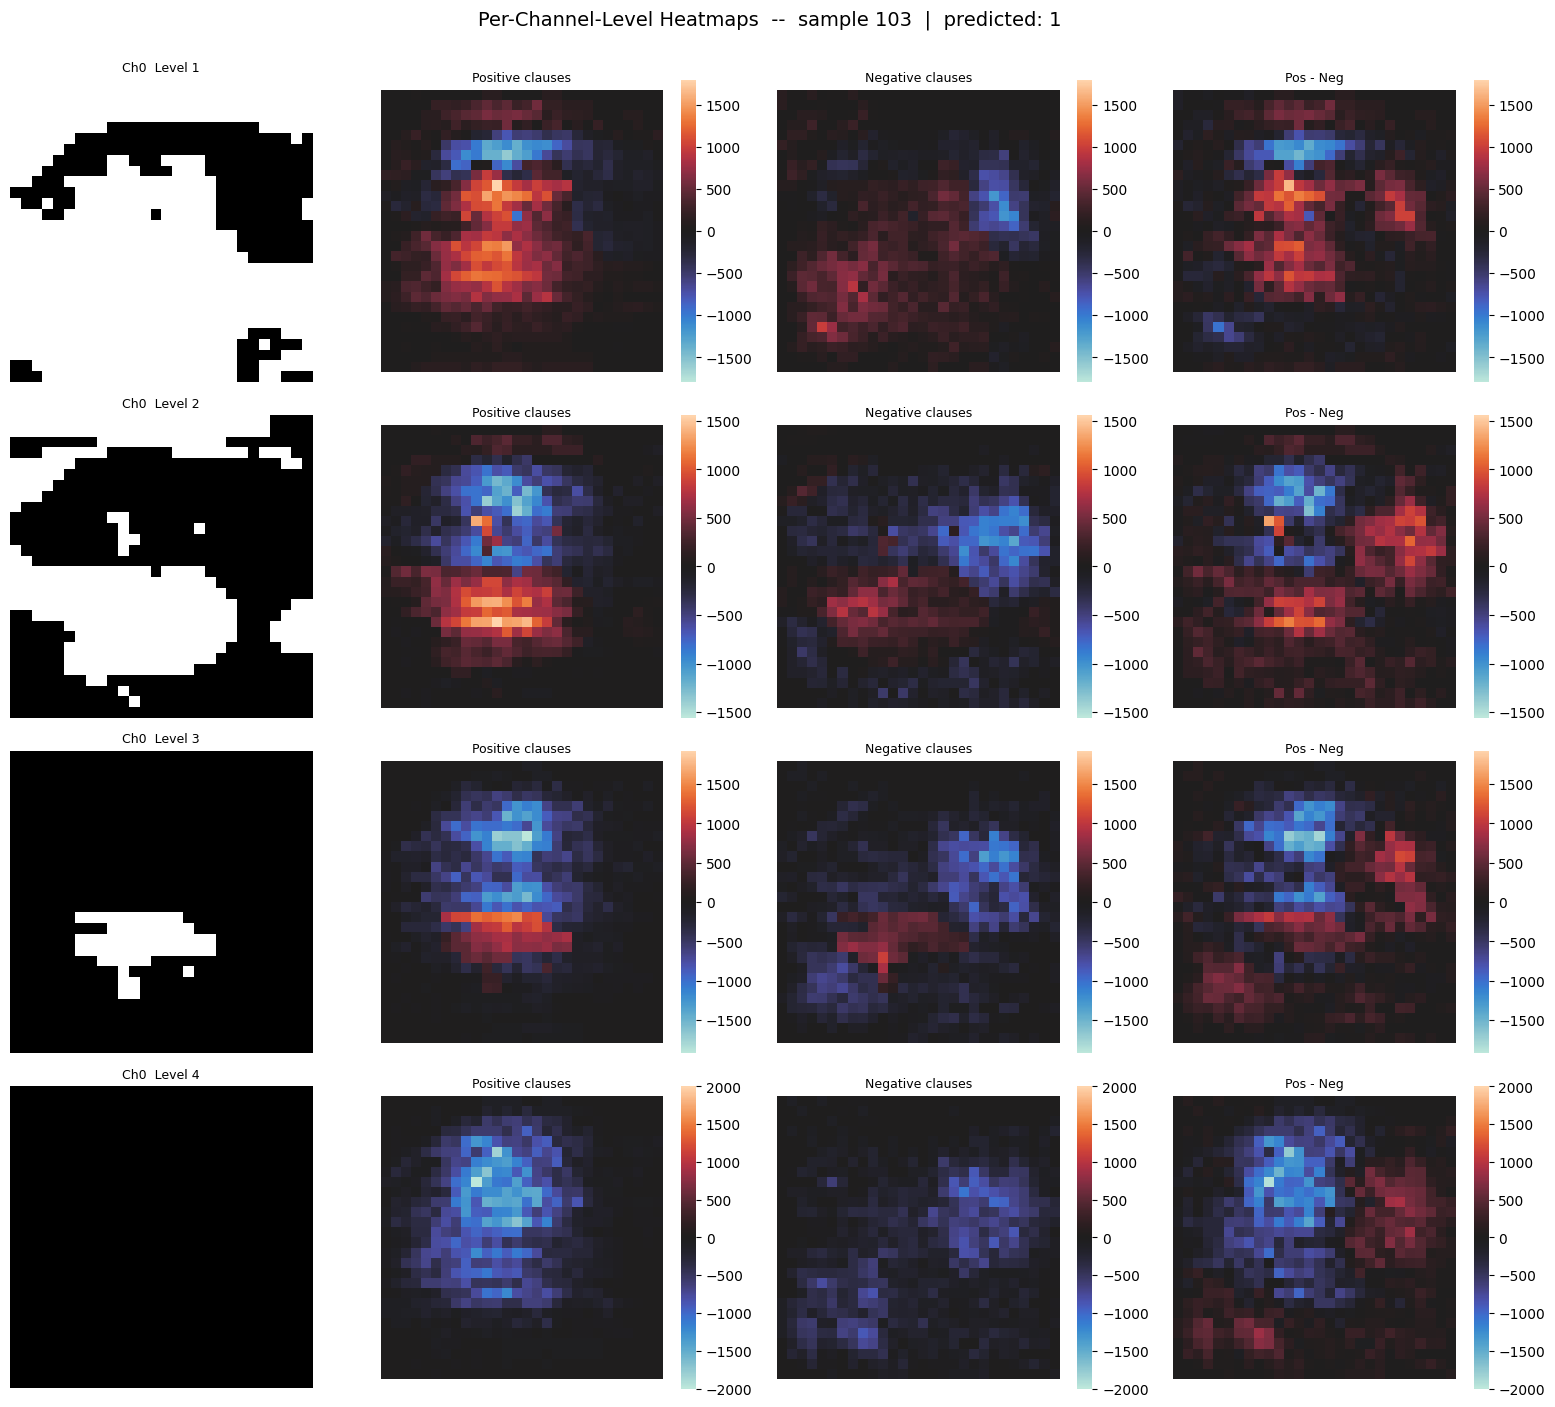

In [17]:
image_index = np.random.randint(0, len(X_test))
print(f"Showing sample index: {image_index}")

visualize_aggregated_heatmap(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=resolution,
    n_channels=1,
    image_shape=(28, 28))

visualize_per_channel_heatmaps(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=resolution,
    n_channels=1,
    image_shape=(28, 28))

visualize_per_channel_level_heatmaps(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=resolution,
    n_channels=1,
    image_shape=(28, 28))
